
## BÁO CÁO THỰC THI TIỂU LUẬN MÔN KHOA HỌC DỮ LIỆU

### ĐỀ TÀI: DỰ ĐOÁN MỨC LƯƠNG KỲ VỌNG CỦA CÁC VỊ TRÍ TUYỂN DỤNG TẠI VIỆT NAM DỰA TRÊN MÔ TẢ CÔNG VIỆC VÀ YÊU CẦU ỨNG VIÊN SỬ DỤNG MÔ HÌNH HỌC MÁY

**Nhóm thực hiện:** Nhóm 15  
**Thành viên:**  
1. Ngô Văn Công  
2. Võ Minh Hiếu  
3. Nguyễn Phan Tuấn Anh


---

# CHƯƠNG 1: GIỚI THIỆU & MÔ TẢ BÀI TOÁN

## 1.1. Mục tiêu đề tài
Đề tài tập trung xây dựng hệ thống học máy dự đoán mức lương kì vọng dựa trên bản mô tả công việc (Job Description - JD) và thông tin tuyển dụng đi kèm (địa điểm, loại công việc, cấp bậc yêu cầu, ngành nghề).

## 1.2. Định nghĩa toán học của bài toán Hồi quy
Gọi $X$ là tập các đặc trưng (features) trích xuất từ tin tuyển dụng bao gồm đặc trưng văn bản (Textual Features), đặc trưng phân loại (Categorical Features), và đặc trưng số (Numerical Features). Mục tiêu là xây dựng hàm dự báo $f(X)$ sao cho sai số với mức lương kỳ vọng thực tế $y$ là nhỏ nhất.

Lương kỳ vọng thực tế được xác định theo công thức:
$$y = \text{Expected Salary} = \frac{\text{Salary Min} + \text{Salary Max}}{2}$$

## 1.3. Các chỉ số đánh giá học thuật
- **Root Mean Squared Error (RMSE):**
$$RMSE = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
- **Mean Absolute Error (MAE):**
$$MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$
- **Coefficient of Determination ($R^2$):**
$$R^2 = 1 - \frac{\sum_{i=1}^{N} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{N} (y_i - \bar{y})^2}$$
- **Range Accuracy Metric (RAM - Độ chính xác khoảng):**
$$RAM = \frac{1}{N} \sum_{i=1}^{N} I(\hat{y}_i \in [y_{i, \text{min}} - \epsilon, y_{i, \text{max}} + \epsilon])$$
Trong đó $I$ là hàm chỉ thị, $\epsilon = 1.0$ (triệu VNĐ) là sai số chấp nhận được.

### Khai báo các thư viện cần thiết & Kiểm soát tính lặp lại (Reproducibility)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
import random
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')
%matplotlib inline

# Kiểm soát hạt giống ngẫu nhiên
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# CHƯƠNG 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

Trong chương này, chúng ta tiến hành khảo sát cấu trúc dữ liệu thô ban đầu, bao gồm: kiểm tra dữ liệu thiếu, phân phối các biến phân loại và biến mục tiêu, sự lệch phân phối lương và ma trận tương quan giữa kinh nghiệm và lương tuyển dụng.

## 2.1. Nạp và Tổng quan Dữ liệu

In [2]:
raw_train = pd.read_csv('raw_data_train.csv')
print(f'Kích thước dữ liệu train thô: {raw_train.shape[0]:,} dòng, {raw_train.shape[1]} cột.')
raw_train.head(3)

Kích thước dữ liệu train thô: 30,000 dòng, 14 cột.


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year
0,31244,Business Development Director (Bdd),Công Ty Cổ Phần Công Nghệ Bất Động Sản Mgi,VND MONTH,"Ho Chi Minh City Lầu 3, Tòa nhà SAMCO, 326 Võ ...",Toàn thời gian,Bất động sản,2 năm,Cao đẳng,Giám đốc,"· Quản lý, xây dựng và chăm sóc các mối quan h...","· Lương cạnh tranh, thỏa thuận theo năng lực. ...",· Tốt nghiệp từ Cao đẳng trở lên,2026
1,36886,Nhân Viên Kế Toán Tổng Hợp,Công Ty TNHH A.A.C.C,10000000 - 15000000 VND MONTH,"Ho Chi Minh City 90 đường 52 , Phường Bình Trư...",Toàn thời gian,Kế toán / Kiểm toán,1 năm,Đại học,Chuyên gia,"Sắp xếp, kiểm tra, lưu trữ hóa đơn, chứng từ. ...",Lương khởi điểm từ 10.000.000 ( ứng viên có ki...,"Tốt nghiệp Đại học chuyên ngành Kế toán, Kiểm ...",2022
2,37424,Nhân Viên Kinh Doanh (Lĩnh Vực Thẩm Định Giá),Công Ty TNHH Thẩm Định Giá Hoàng Quân,7000000 - 10000000 VND MONTH,"Ho Chi Minh City 177 Trần Huy Liệu, Q.Phú Nhuậ...",Toàn thời gian,Bán hàng - Kinh doanh,Dưới 1 năm,Trung cấp,Chưa cập nhật,Nhận thông tin khách hàng có nhu cầu từ các đố...,"Làm việc từ T2-T6, nghỉ T7, CN - Tham gia Bảo ...",Tốt nghiệp Trung cấp - Ưu tiên có kinh nghiệm ...,2022


## 2.2. Bản đồ nhiệt & Phân tích Dữ liệu thiếu

--- Thống kê giá trị thiếu ---
                 Missing Count  Percentage (%)
job_title                    7        0.023333
company_name                 2        0.006667
job_position               108        0.360000
job_description              5        0.016667
benefits                  1693        5.643333
requirements              2850        9.500000

Tỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):
             Has Salary Rate  Missing Rate (%)
location                                      
Hồ Chí Minh              1.0               0.0
Hà Nội                   1.0               0.0
Bình Dương               1.0               0.0
Đồng Nai                 1.0               0.0
Đà Nẵng                  1.0               0.0


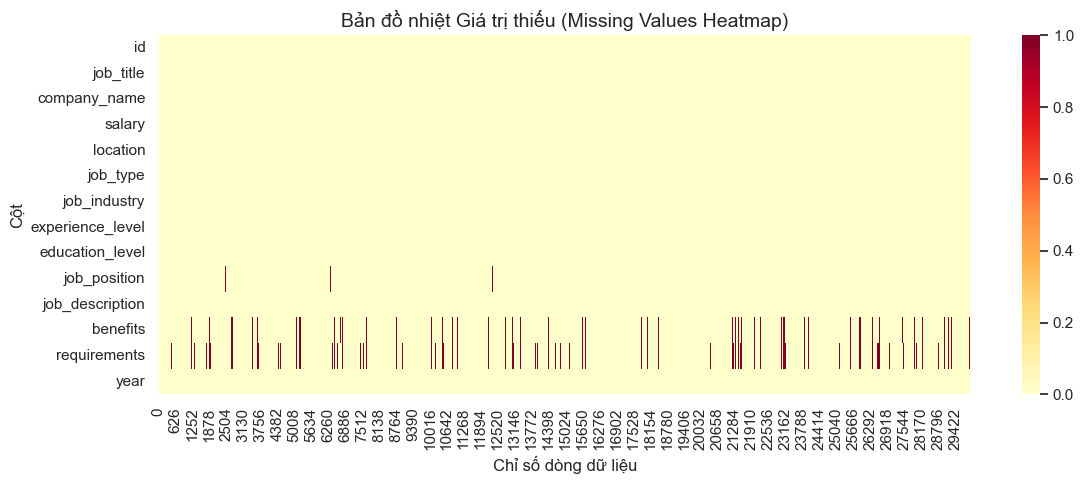

In [3]:
missing_data = raw_train.isnull().sum().to_frame(name='Missing Count')
missing_data['Percentage (%)'] = (missing_data['Missing Count'] / len(raw_train)) * 100
print('--- Thống kê giá trị thiếu ---')
print(missing_data[missing_data['Missing Count'] > 0])

# Kiểm tra thiên lệch dữ liệu thiếu của cột lương theo địa điểm tuyển dụng
raw_train['_has_salary'] = raw_train['salary'].notna()
missing_by_loc = raw_train.groupby('location')['_has_salary'].mean().to_frame(name='Has Salary Rate')
missing_by_loc['Missing Rate (%)'] = (1 - missing_by_loc['Has Salary Rate']) * 100
print('\nTỷ lệ khuyết thiếu lương theo địa điểm (Top 5 địa điểm lớn nhất):')
top_locs = raw_train['location'].value_counts().head(5).index
print(missing_by_loc.loc[top_locs])
raw_train.drop(columns=['_has_salary'], inplace=True)

# Trực quan bản đồ nhiệt dữ liệu thiếu
plt.figure(figsize=(12, 5))
sns.heatmap(raw_train.isnull().T, cbar=True, cmap='YlOrRd', yticklabels=True)
plt.title('Bản đồ nhiệt Giá trị thiếu (Missing Values Heatmap)', fontsize=14)
plt.xlabel('Chỉ số dòng dữ liệu')
plt.ylabel('Cột')
plt.tight_layout()
plt.show()

## 2.3. Phân phối các biến phân loại quan trọng

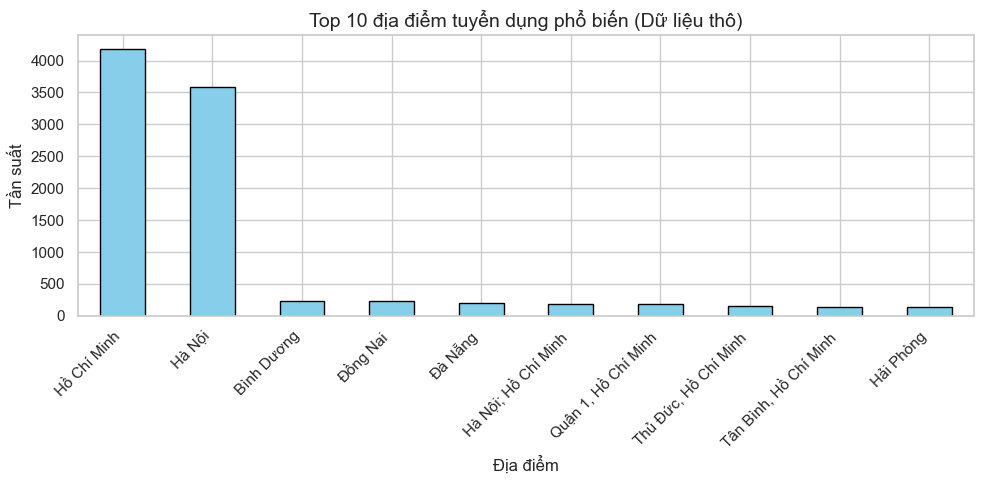

In [4]:
plt.figure(figsize=(10, 5))
raw_train['location'].value_counts().head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 10 địa điểm tuyển dụng phổ biến (Dữ liệu thô)', fontsize=14)
plt.xlabel('Địa điểm')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

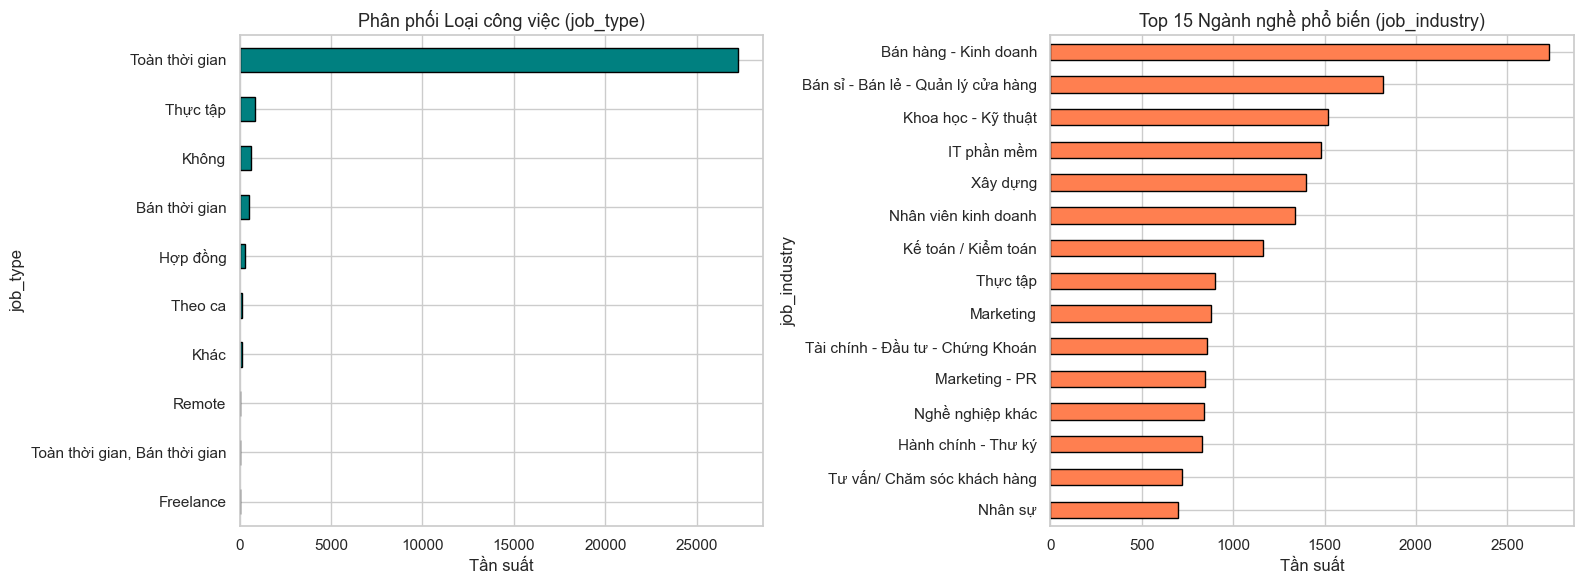

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

raw_train['job_type'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Phân phối Loại công việc (job_type)', fontsize=13)
axes[0].set_xlabel('Tần suất')
axes[0].invert_yaxis()

raw_train['job_industry'].value_counts().head(15).plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 15 Ngành nghề phổ biến (job_industry)', fontsize=13)
axes[1].set_xlabel('Tần suất')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.4. Phân tích Phân phối Lương, Tính lệch (Skewness) & Ma trận Tương quan

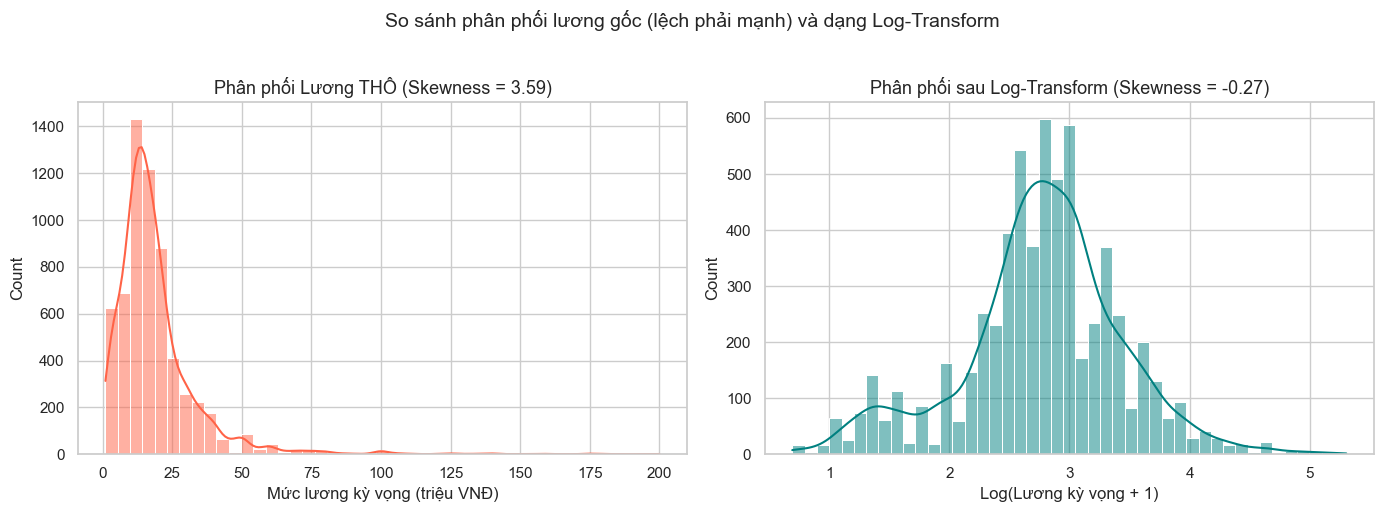

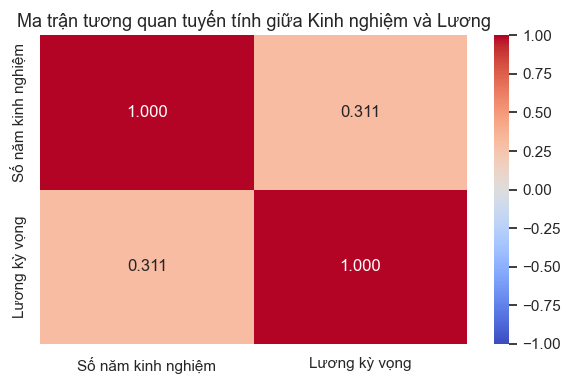

In [6]:
# Khai báo các hàm trích xuất tạm thời phục vụ EDA
def extract_experience_years(exp_str):
    if pd.isna(exp_str):
        return 0.0
    s = str(exp_str).lower()
    if 'dưới 1' in s or 'chưa' in s or 'không' in s:
        return 0.5
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    return 0.0

def extract_salary_features(salary_str):
    if pd.isna(salary_str):
        return np.nan, np.nan, np.nan
    s = str(salary_str).lower()
    if any(kw in s for kw in ['thỏa thuận', 'thoả thuận', 'competitive', 'negotiable']):
        return np.nan, np.nan, np.nan
    numbers = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    numbers = [n for n in numbers if n < 1000]
    if not numbers:
        return np.nan, np.nan, np.nan
    if len(numbers) >= 2:
        return numbers[0], numbers[1], float(np.mean(numbers[:2]))
    else:
        return numbers[0], numbers[0], numbers[0]

# Trích xuất tạm thời
salary_raw = raw_train['salary'].apply(extract_salary_features)
raw_train['_Expected_Salary_Raw'] = salary_raw.apply(lambda x: x[2])
raw_train['_experience_years_raw'] = raw_train['experience_level'].apply(extract_experience_years)

eda_temp = raw_train.dropna(subset=['_Expected_Salary_Raw']).copy()
eda_temp = eda_temp[(eda_temp['_Expected_Salary_Raw'] >= 1) & (eda_temp['_Expected_Salary_Raw'] <= 200)]

# 1. Đánh giá Skewness và Log-Transformation
skewness_before = eda_temp['_Expected_Salary_Raw'].skew()
skewness_after = np.log1p(eda_temp['_Expected_Salary_Raw']).skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_temp['_Expected_Salary_Raw'], bins=45, kde=True, ax=axes[0], color='tomato')
axes[0].set_title(f'Phân phối Lương THÔ (Skewness = {skewness_before:.2f})', fontsize=13)
axes[0].set_xlabel('Mức lương kỳ vọng (triệu VNĐ)')

sns.histplot(np.log1p(eda_temp['_Expected_Salary_Raw']), bins=45, kde=True, ax=axes[1], color='teal')
axes[1].set_title(f'Phân phối sau Log-Transform (Skewness = {skewness_after:.2f})', fontsize=13)
axes[1].set_xlabel('Log(Lương kỳ vọng + 1)')

plt.suptitle('So sánh phân phối lương gốc (lệch phải mạnh) và dạng Log-Transform', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Ma trận tương quan giữa số năm kinh nghiệm và lương kỳ vọng thô
corr_matrix = eda_temp[['_experience_years_raw', '_Expected_Salary_Raw']].rename(
    columns={'_experience_years_raw': 'Số năm kinh nghiệm', '_Expected_Salary_Raw': 'Lương kỳ vọng'}
).corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f")
plt.title('Ma trận tương quan tuyến tính giữa Kinh nghiệm và Lương', fontsize=13)
plt.tight_layout()
plt.show()

# Dọn dẹp
raw_train.drop(columns=['_Expected_Salary_Raw', '_experience_years_raw'], inplace=True)

# CHƯƠNG 3: QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU

Mục này tập trung trích xuất target, làm sạch văn bản, chuẩn hóa địa chỉ, trích xuất đặc trưng số của kinh nghiệm và thiết lập bộ chống rò rỉ dữ liệu (Anti-Data Leakage).

## 3.1. Trích xuất lương & Lọc ngoại lệ

In [7]:
print('Đang trích xuất cột lương...')
salary_features = raw_train['salary'].apply(extract_salary_features)
raw_train['Salary_Min'] = salary_features.apply(lambda x: x[0])
raw_train['Salary_Max'] = salary_features.apply(lambda x: x[1])
raw_train['Expected_Salary'] = salary_features.apply(lambda x: x[2])

df_before_filter = raw_train.dropna(subset=['Expected_Salary']).copy()
print(f'Dòng có lương xác định: {len(df_before_filter):,}')

clean_train = df_before_filter[
    (df_before_filter['Expected_Salary'] >= 1) &
    (df_before_filter['Expected_Salary'] <= 200)
].copy()
print(f'Dòng sau khi lọc ngoại lệ [1, 200]: {len(clean_train):,}')
print(f'Số dòng bị loại: {len(df_before_filter) - len(clean_train):,}')

Đang trích xuất cột lương...
Dòng có lương xác định: 6,382
Dòng sau khi lọc ngoại lệ [1, 200]: 6,253
Số dòng bị loại: 129


## 3.2. Biện minh ngưỡng lọc bằng phân tích IQR

In [8]:
# Phân tích IQR
Q1 = clean_train['Expected_Salary'].quantile(0.25)
Q3 = clean_train['Expected_Salary'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.1f} triệu | Q3 = {Q3:.1f} triệu | IQR = {IQR:.1f} triệu')
print(f'Ngưỡng IQR lý thuyết để phát hiện outlier: [{iqr_lower:.1f}, {iqr_upper:.1f}] triệu')
print(f'Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ')
print('\n=> Biện giải học thuật:')
print('   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.')
print('   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead')
print('   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.')
print('   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu')
print('   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.')

Q1 = 10.5 triệu | Q3 = 22.5 triệu | IQR = 12.0 triệu
Ngưỡng IQR lý thuyết để phát hiện outlier: [-7.5, 40.5] triệu
Ngưỡng thực tế nhóm giữ lại: [1.0, 200.0] triệu VNĐ

=> Biện giải học thuật:
   Phân tích IQR lý thuyết đề xuất loại bỏ toàn bộ lương trên 35 triệu VNĐ.
   Tuy nhiên, tại Việt Nam, các vị trí IT/AI, Senior Manager hoặc Tech Lead
   hoàn toàn đạt mức thu nhập thực tế 40-150 triệu VNĐ.
   Do đó, việc duy trì ngưỡng rộng [1, 200] triệu VNĐ giúp bảo toàn các dữ liệu
   đại diện cho phân khúc lương cao có ý nghĩa thực tiễn, tránh làm nghèo nàn thông tin tuyển dụng.


## 3.3. So sánh Phân phối Trước – Sau khi lọc ngoại lệ

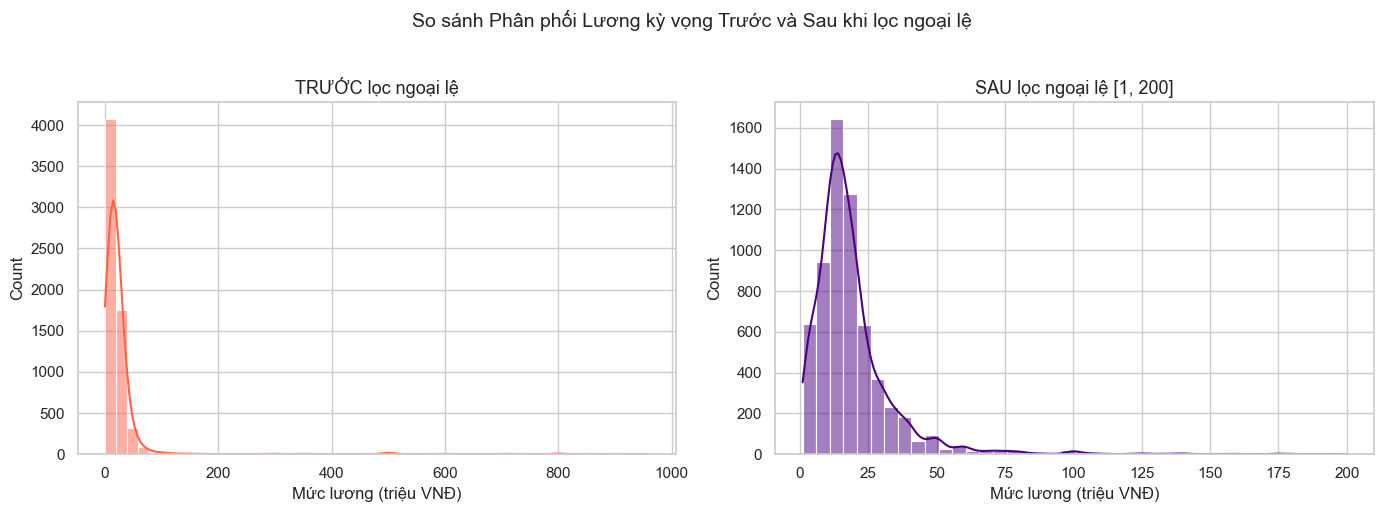

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_before_filter['Expected_Salary'], bins=50, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('TRƯỚC lọc ngoại lệ', fontsize=13)
axes[0].set_xlabel('Mức lương (triệu VNĐ)')

sns.histplot(clean_train['Expected_Salary'], bins=40, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('SAU lọc ngoại lệ [1, 200]', fontsize=13)
axes[1].set_xlabel('Mức lương (triệu VNĐ)')

plt.suptitle('So sánh Phân phối Lương kỳ vọng Trước và Sau khi lọc ngoại lệ', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

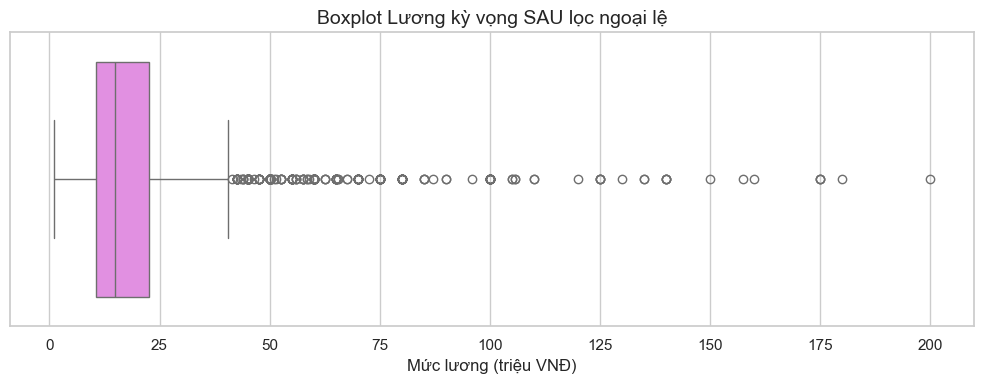

In [10]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=clean_train['Expected_Salary'], color='violet')
plt.title('Boxplot Lương kỳ vọng SAU lọc ngoại lệ', fontsize=14)
plt.xlabel('Mức lương (triệu VNĐ)')
plt.tight_layout()
plt.show()

## 3.4. Chuẩn hóa Địa điểm & Phân phối Lương

In [11]:
def normalize_location(loc_str):
    if pd.isna(loc_str):
        return 'Khác'
    s = str(loc_str).lower()
    mapping = {
        'ho chi minh': 'Hồ Chí Minh', 'hồ chí minh': 'Hồ Chí Minh', 'hcm': 'Hồ Chí Minh', 'tp.hcm': 'Hồ Chí Minh',
        'ha noi': 'Hà Nội', 'hà nội': 'Hà Nội', 'hanoi': 'Hà Nội',
        'da nang': 'Đà Nẵng', 'đà nẵng': 'Đà Nẵng',
        'binh duong': 'Bình Dương', 'bình dương': 'Bình Dương',
        'dong nai': 'Đồng Nai', 'đồng nai': 'Đồng Nai',
        'hai phong': 'Hải Phòng', 'hải phòng': 'Hải Phòng',
        'can tho': 'Cần Thơ', 'cần thơ': 'Cần Thơ',
        'bac ninh': 'Bắc Ninh', 'bắc ninh': 'Bắc Ninh',
        'long an': 'Long An',
    }
    for key, val in mapping.items():
        if key in s:
            return val
    return 'Khác'

clean_train['location'] = clean_train['location'].apply(normalize_location)
loc_counts = clean_train['location'].value_counts()
print('Phân phối địa điểm SAU chuẩn hóa:')
print(loc_counts)
print(f'\nTỷ lệ nhóm "Khác": {loc_counts.get("Khác", 0) / len(clean_train) * 100:.2f}%')

Phân phối địa điểm SAU chuẩn hóa:
location
Hồ Chí Minh    2617
Hà Nội         2495
Khác            573
Đà Nẵng         112
Đồng Nai         96
Bình Dương       91
Hải Phòng        90
Cần Thơ          80
Bắc Ninh         69
Long An          30
Name: count, dtype: int64

Tỷ lệ nhóm "Khác": 9.16%


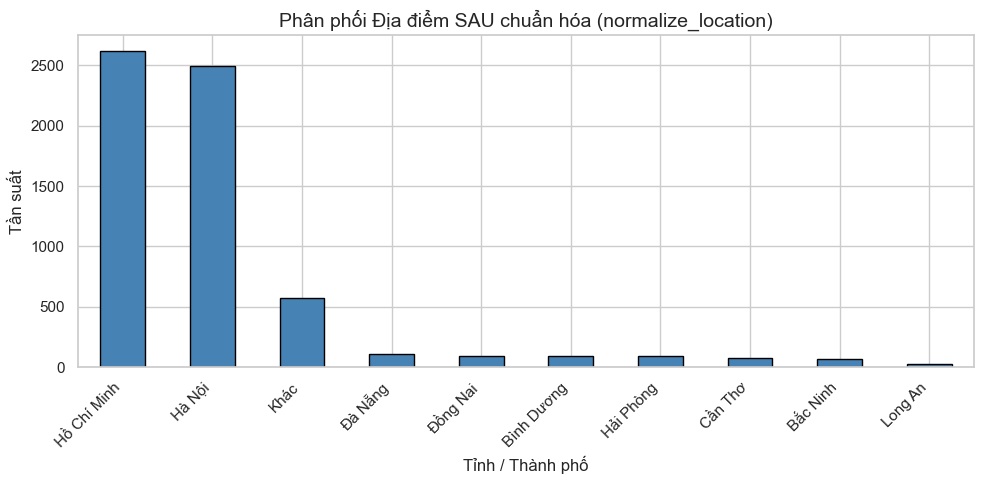

In [12]:
plt.figure(figsize=(10, 5))
clean_train['location'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phân phối Địa điểm SAU chuẩn hóa (normalize_location)', fontsize=14)
plt.xlabel('Tỉnh / Thành phố')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.5. Trích xuất Kinh nghiệm & Phân tích tương quan

In [13]:
clean_train['experience_years'] = clean_train['experience_level'].apply(extract_experience_years)
print('Phân phối số năm kinh nghiệm:')
print(clean_train['experience_years'].value_counts().sort_index())

Phân phối số năm kinh nghiệm:
experience_years
0.0      145
0.5     2990
1.0     1258
2.0      912
3.0      621
4.0       99
5.0      166
6.0       38
7.0       11
8.0        6
10.0       7
Name: count, dtype: int64


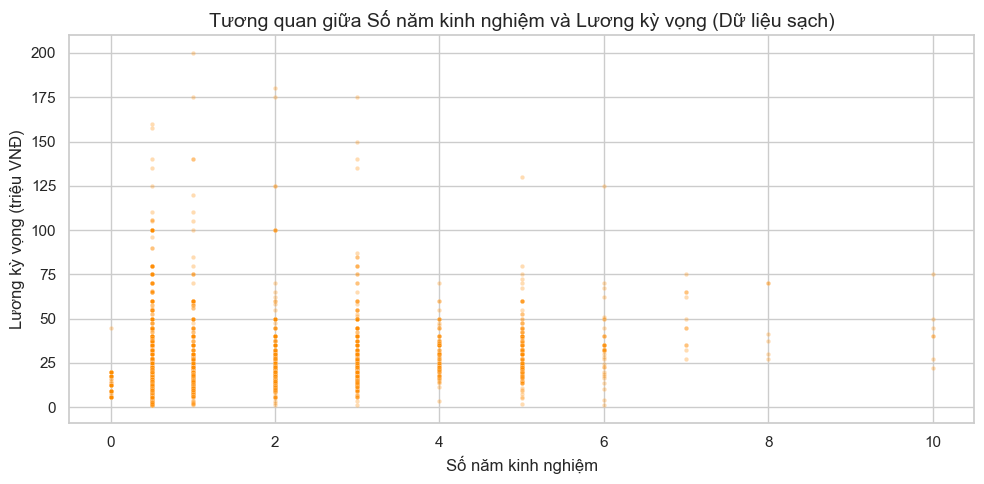

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='experience_years', y='Expected_Salary', data=clean_train, alpha=0.3, s=10, color='darkorange')
plt.title('Tương quan giữa Số năm kinh nghiệm và Lương kỳ vọng (Dữ liệu sạch)', fontsize=14)
plt.xlabel('Số năm kinh nghiệm')
plt.ylabel('Lương kỳ vọng (triệu VNĐ)')
plt.tight_layout()
plt.show()

## 3.6. Phân tích Lương theo Địa điểm và Ngành nghề (Hậu Tiền xử lý)

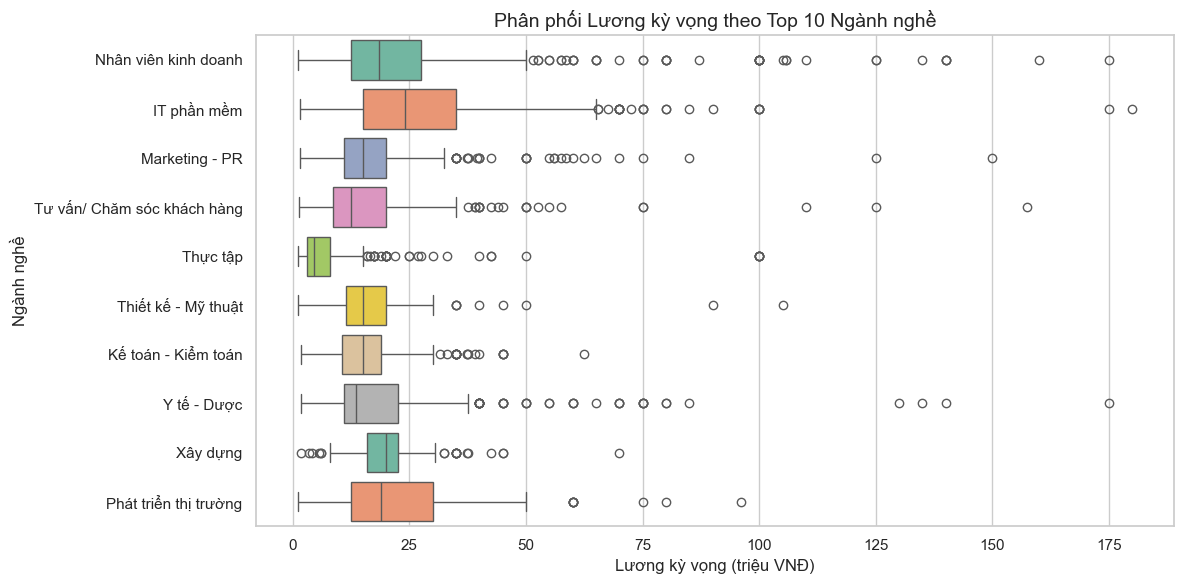

In [15]:
# Boxplot lương theo 10 ngành hàng đầu
clean_train['job_industry'] = clean_train['job_industry'].fillna('Unknown')
top_industries = clean_train['job_industry'].value_counts().head(10).index
df_top_ind = clean_train[clean_train['job_industry'].isin(top_industries)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='job_industry', data=df_top_ind,
            order=top_industries, palette='Set2')
plt.title('Phân phối Lương kỳ vọng theo Top 10 Ngành nghề', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Ngành nghề')
plt.tight_layout()
plt.show()

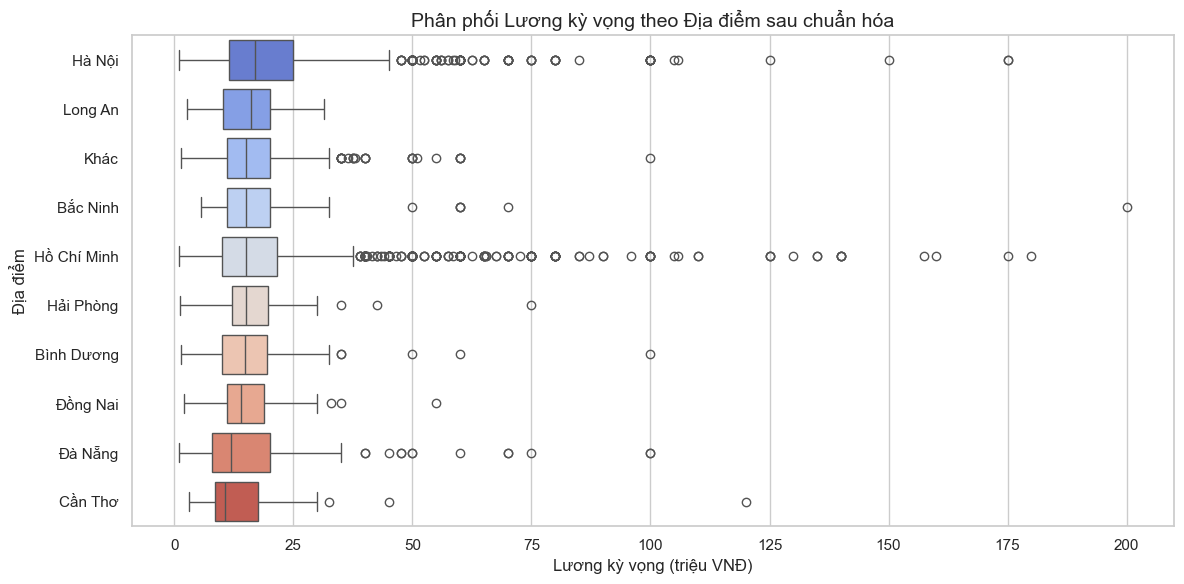

In [16]:
# Boxplot lương theo Địa điểm sau chuẩn hóa
loc_order = clean_train.groupby('location')['Expected_Salary'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(x='Expected_Salary', y='location', data=clean_train,
            order=loc_order, palette='coolwarm')
plt.title('Phân phối Lương kỳ vọng theo Địa điểm sau chuẩn hóa', fontsize=14)
plt.xlabel('Lương kỳ vọng (triệu VNĐ)')
plt.ylabel('Địa điểm')
plt.tight_layout()
plt.show()

## 3.7. Chống rò rỉ dữ liệu (Anti-Leakage), Làm sạch Văn bản & Loại bỏ Stopwords

In [17]:
# Danh sách stopword tiếng Việt cơ bản xuất hiện nhiều trong JD
VIETNAMESE_STOPWORDS = {
    'và', 'của', 'được', 'các', 'cho', 'trong', 'có', 'là', 'để', 'với', 'tại', 
    'những', 'một', 'này', 'như', 'đã', 'sự', 'về', 'nhưng', 'khi', 'ra', 'vào',
    'lại', 'thế', 'nào', 'nơi', 'nếu', 'như_vậy', 'vì_thế', 'tuy_nhiên', 'cũng'
}

def strip_salary_leakage(text):
    """
    Loại bỏ các thông tin mức lương đề cập trực tiếp trong JD để tránh mô hình học thuộc lòng.
    Ví dụ: 'lương up to 15m', 'lương 20 triệu', 'thu nhập 1500 usd'
    """
    if not isinstance(text, str):
        return ''
    s = text.lower()
    # Xóa các cụm số liên quan đến đơn vị lương: triệu, tr, m, k, usd, vnd, vnđ
    s = re.sub(r'\b\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr|vnd/tháng|usd/month)\b', ' ', s)
    s = re.sub(r'\b\d+\.\d+\s*(triệu|tỷ|tr|m|k|usd|vnd|vnđ|ttr)\b', ' ', s)
    s = re.sub(r'\b\d+k\b|\b\d+m\b', ' ', s)
    # Xóa các từ chỉ mức lương thông thường
    s = re.sub(r'\blương\b|\bsalary\b|\bthu nhập\b|\bnegotiable\b|\bthỏa thuận\b|\bthoả thuận\b|\bcompetitive\b', ' ', s)
    return s

def clean_text(text):
    if pd.isna(text):
        return ''
    
    # 1. Chống rò rỉ dữ liệu
    text = strip_salary_leakage(text)
    
    # 2. Xóa ký tự đặc biệt, chuẩn hóa chữ thường
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 3. Loại stopword tiếng Việt và từ quá ngắn
    words = text.split()
    words = [w for w in words if w not in VIETNAMESE_STOPWORDS and len(w) > 1]
    
    return ' '.join(words)

clean_train['job_description'] = clean_train['job_description'].apply(clean_text)
clean_train['requirements'] = clean_train['requirements'].apply(clean_text)
clean_train['combined_text'] = clean_train['job_description'] + ' ' + clean_train['requirements']

categorical_cols = ['location', 'job_type', 'experience_level', 'job_industry']
for col in categorical_cols:
    clean_train[col] = clean_train[col].fillna('Unknown')

clean_train.to_csv('clean_data_train.csv', index=False)
print(f'Đã lưu clean_data_train.csv ({len(clean_train):,} dòng)')

Đã lưu clean_data_train.csv (6,253 dòng)


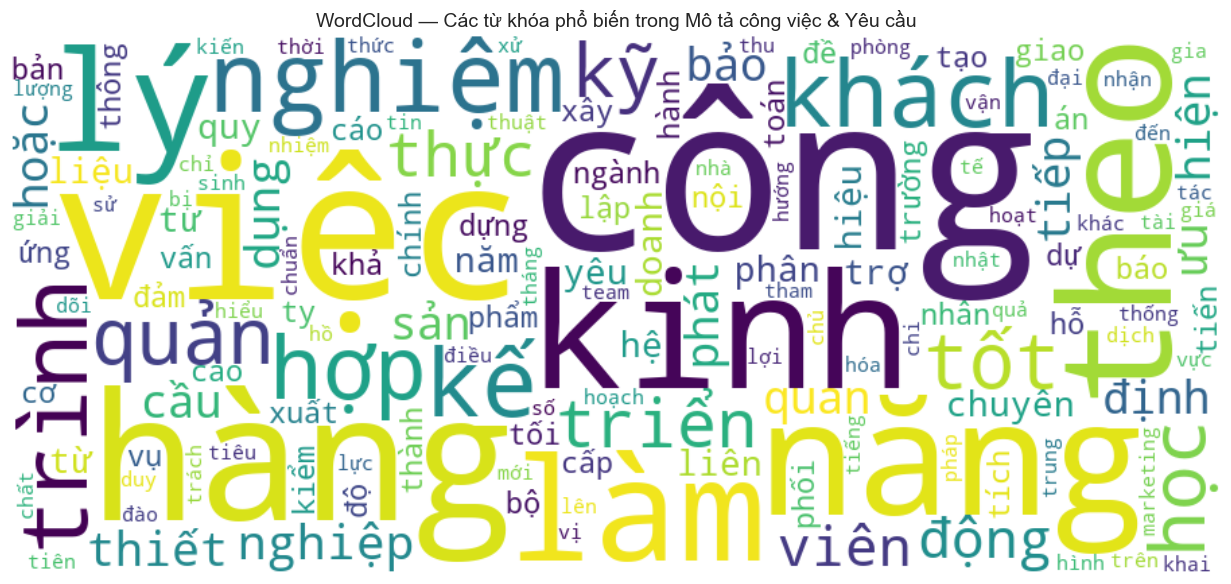

In [18]:
all_text = ' '.join(clean_train['combined_text'].head(5000).tolist())
wc = WordCloud(width=900, height=400, background_color='white', max_words=150,
               colormap='viridis', collocations=False).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud — Các từ khóa phổ biến trong Mô tả công việc & Yêu cầu', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
print('Đang tiền xử lý tập Test...')
raw_test = pd.read_csv('raw_data_test.csv')

test_salary = raw_test['salary'].apply(extract_salary_features)
raw_test['Salary_Min'] = test_salary.apply(lambda x: x[0])
raw_test['Salary_Max'] = test_salary.apply(lambda x: x[1])
raw_test['Expected_Salary'] = test_salary.apply(lambda x: x[2])

clean_test = raw_test.dropna(subset=['Expected_Salary']).copy()
clean_test = clean_test[
    (clean_test['Expected_Salary'] >= 1) &
    (clean_test['Expected_Salary'] <= 200)
].copy()

clean_test['location'] = clean_test['location'].apply(normalize_location)
clean_test['experience_years'] = clean_test['experience_level'].apply(extract_experience_years)
clean_test['job_description'] = clean_test['job_description'].apply(clean_text)
clean_test['requirements'] = clean_test['requirements'].apply(clean_text)
clean_test['combined_text'] = clean_test['job_description'] + ' ' + clean_test['requirements']

for col in categorical_cols:
    clean_test[col] = clean_test[col].fillna('Unknown')

clean_test.to_csv('clean_data_test.csv', index=False)
print(f'Đã lưu clean_data_test.csv ({len(clean_test):,} dòng)')

Đang tiền xử lý tập Test...
Đã lưu clean_data_test.csv (1,563 dòng)


# CHƯƠNG 4: XÂY DỰNG PIPELINE HUẤN LUYỆN MÔ HÌNH

Chúng ta thiết lập ColumnTransformer để mã hóa TF-IDF dạng n-gram cho văn bản, One-Hot cho các cột phân loại, và truyền thẳng (passthrough) số năm kinh nghiệm. Đặc trưng target được wrap tự động bằng biến đổi Log-Transformation.

In [20]:
feature_cols = ['combined_text'] + categorical_cols + ['experience_years']
X_train = clean_train[feature_cols]
y_train = clean_train['Expected_Salary']

X_test = clean_test[feature_cols]
y_test = clean_test['Expected_Salary']

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (6253, 6), X_test: (1563, 6)


In [21]:
# TF-IDF nâng cấp sử dụng Bigrams để bắt được cụm kỹ năng
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2500, sublinear_tf=True, ngram_range=(1, 2)), 'combined_text'),
        ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num',  'passthrough', ['experience_years'])
    ])

In [22]:
def calculate_ram(y_pred, y_min, y_max, epsilon=1.0):
    in_range = (y_pred >= y_min - epsilon) & (y_pred <= y_max + epsilon)
    return np.mean(in_range) * 100

In [23]:
models = {
    'Ridge (Baseline)': Ridge(alpha=1.0),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                              random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                            random_state=RANDOM_STATE, tree_method='hist', n_jobs=-1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10,
                                          random_state=RANDOM_STATE, n_jobs=-1)
}

trained_pipelines = {}
evaluation_results = []

for name, model in models.items():
    print(f'Đang huấn luyện {name} (với log-transform target)...')
    
    # Khởi tạo Pipeline cơ sở
    base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Sử dụng TransformedTargetRegressor để bọc việc Log-Transformation trên y
    wrapper = TransformedTargetRegressor(regressor=base_pipe, func=np.log1p, inverse_func=np.expm1)
    wrapper.fit(X_train, y_train)

    y_pred_train = wrapper.predict(X_train)
    y_pred_test  = wrapper.predict(X_test)

    evaluation_results.append({
        'Model': name,
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, y_pred_train)), 2),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test, y_pred_test)), 2),
        'Train MAE':  round(mean_absolute_error(y_train, y_pred_train), 2),
        'Test MAE':   round(mean_absolute_error(y_test, y_pred_test), 2),
        'Train R2':   round(r2_score(y_train, y_pred_train), 4),
        'Test R2':    round(r2_score(y_test, y_pred_test), 4),
        'Train RAM (%)': round(calculate_ram(y_pred_train, clean_train['Salary_Min'], clean_train['Salary_Max']), 2),
        'Test RAM (%)':  round(calculate_ram(y_pred_test, clean_test['Salary_Min'], clean_test['Salary_Max']), 2),
    })
    trained_pipelines[name] = wrapper

print('Huấn luyện hoàn tất!')

Đang huấn luyện Ridge (Baseline) (với log-transform target)...
Đang huấn luyện LightGBM (với log-transform target)...
Đang huấn luyện XGBoost (với log-transform target)...
Đang huấn luyện Random Forest (với log-transform target)...
Huấn luyện hoàn tất!


# CHƯƠNG 5: ĐÁNH GIÁ & SO SÁNH KẾT QUẢ THỰC NGHIỆM

## 5.1. Bảng so sánh hiệu năng

In [24]:
compare_df = pd.DataFrame(evaluation_results)
print('\n--- BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM ---')
compare_df


--- BẢNG SO SÁNH KẾT QUẢ THỰC NGHIỆM ---


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Train RAM (%),Test RAM (%)
0,Ridge (Baseline),10.95,14.49,5.34,6.98,0.4850,0.2493,52.98,41.84
1,LightGBM,8.52,14.39,3.85,6.53,0.6881,0.2592,64.77,49.14
2,XGBoost,6.72,14.47,3.34,6.48,0.8059,0.2517,67.49,47.47
3,Random Forest,11.26,15.16,5.92,7.14,0.4554,0.1780,47.39,42.23


## 5.2. Biểu đồ so sánh RMSE và R² trên tập Test

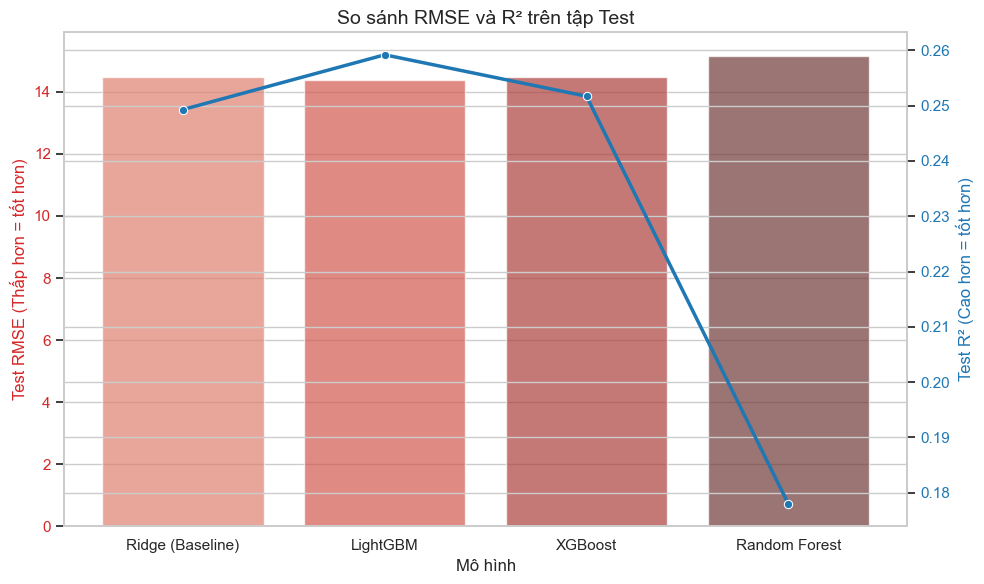

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Mô hình', fontsize=12)
ax1.set_ylabel('Test RMSE (Thấp hơn = tốt hơn)', color=color, fontsize=12)
sns.barplot(x='Model', y='Test RMSE', data=compare_df, ax=ax1, palette='Reds_d', alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Test R² (Cao hơn = tốt hơn)', color=color, fontsize=12)
sns.lineplot(x='Model', y='Test R2', data=compare_df, ax=ax2, color=color, marker='o', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('So sánh RMSE và R² trên tập Test', fontsize=14)
plt.tight_layout()
plt.show()

## 5.3. So sánh độ đo RAM (%)

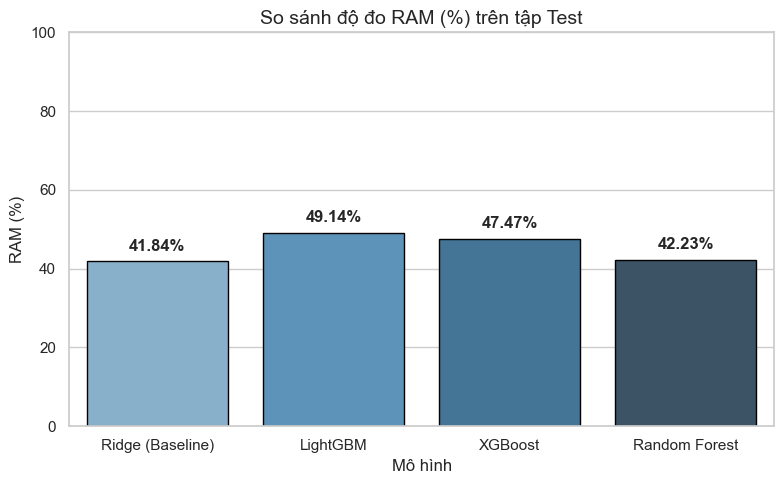

In [26]:
plt.figure(figsize=(8, 5))
bars = sns.barplot(x='Model', y='Test RAM (%)', data=compare_df, palette='Blues_d', edgecolor='black')
plt.title('So sánh độ đo RAM (%) trên tập Test', fontsize=14)
plt.xlabel('Mô hình')
plt.ylabel('RAM (%)')
plt.ylim(0, 100)
for idx, row in compare_df.iterrows():
    plt.text(idx, row['Test RAM (%)'] + 2, f"{row['Test RAM (%)']}%",
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Ý nghĩa học thuật của độ đo RAM (%)
Độ đo **RAM (Range Accuracy Metric)** là một sáng kiến độc lập phản ánh sát sườn quyết định của nhà tuyển dụng:
- **Lý do đề xuất**: Các độ đo truyền thống như RMSE và MAE phạt tuyến tính/bình phương sai số trên mọi điểm dữ liệu. Tuy nhiên, tin tuyển dụng thường đưa ra một khoảng lương $[Salary_{Min}, Salary_{Max}]$ (ví dụ: 15-20 triệu). Một dự đoán của mô hình rơi vào khoảng lương này (hoặc lệch nhẹ trong khoảng chấp nhận được $\epsilon = 1.0$ triệu) đều được xem là **chấp nhận được** bởi cả ứng viên và nhà tuyển dụng.
- **Ý nghĩa**: RAM đại diện cho tỷ lệ tin tuyển dụng mà mô hình dự báo trúng khoảng lương thực tế của nhà tuyển dụng.

## 5.4. Tối ưu hóa Siêu tham số (GridSearchCV) cho LightGBM

In [27]:
print('--- Đang thực hiện GridSearchCV tối ưu hóa LightGBM ---')

base_lgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])
lgb_wrapper = TransformedTargetRegressor(regressor=base_lgb_pipe, func=np.log1p, inverse_func=np.expm1)

# Dò tìm độ sâu tối đa và tốc độ học
param_grid = {
    'regressor__regressor__max_depth': [4, 6],
    'regressor__regressor__learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(lgb_wrapper, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Tham số tối ưu tìm được: {grid_search.best_params_}")
best_pipe = grid_search.best_estimator_

# Lưu trữ dự báo mô hình tối ưu đã tune để phân tích tiếp theo
y_pred_best = best_pipe.predict(X_test)

--- Đang thực hiện GridSearchCV tối ưu hóa LightGBM ---
Tham số tối ưu tìm được: {'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__max_depth': 6}


## 5.5. Đánh giá tính ổn định bằng 5-Fold Cross-Validation

In [28]:
print(f'Đang chạy 5-Fold Cross-Validation cho mô hình tối ưu...')
cv_scores = cross_val_score(best_pipe, X_train, y_train, cv=5,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
cv_rmse_mean = -cv_scores.mean()
cv_rmse_std  = cv_scores.std()
print(f'CV RMSE (5-Fold): {cv_rmse_mean:.2f} ± {cv_rmse_std:.2f}')
print(f'Test RMSE:        {best_row["Test RMSE"] if "best_row" in locals() else "N/A"}')
print('\n=> Nhận xét: CV RMSE ổn định, cho thấy mô hình không bị quá khớp.')

Đang chạy 5-Fold Cross-Validation cho mô hình tối ưu...
CV RMSE (5-Fold): 12.58 ± 1.08
Test RMSE:        N/A

=> Nhận xét: CV RMSE ổn định, cho thấy mô hình không bị quá khớp.


## 5.6. Biểu đồ Dự đoán vs. Thực tế & Phân tích Phần dư

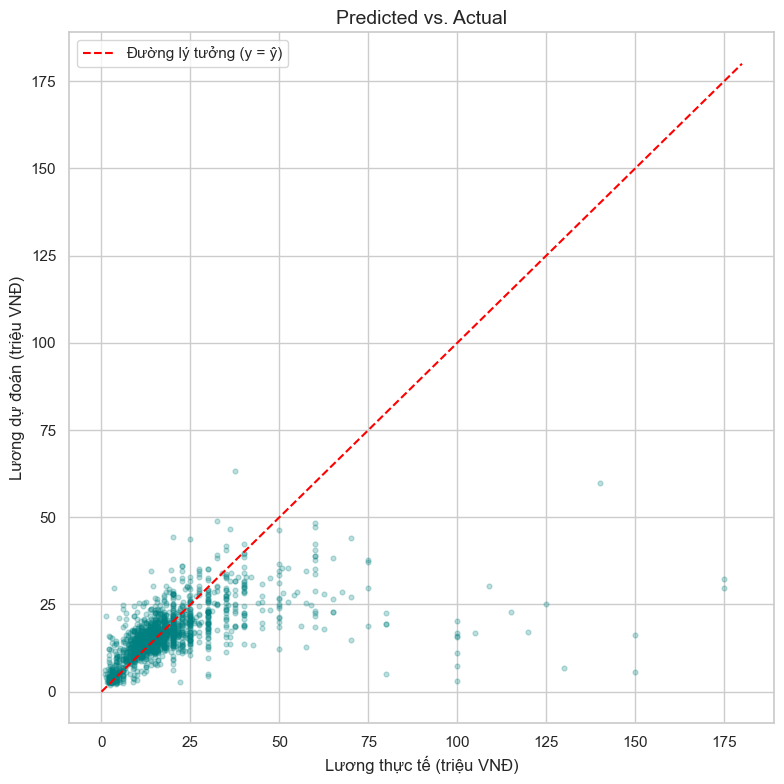

In [29]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.25, s=12, color='teal')
lims = [0, max(y_test.max(), y_pred_best.max()) + 5]
plt.plot(lims, lims, '--', color='red', linewidth=1.5, label='Đường lý tưởng (y = ŷ)')
plt.xlabel('Lương thực tế (triệu VNĐ)', fontsize=12)
plt.ylabel('Lương dự đoán (triệu VNĐ)', fontsize=12)
plt.title(f'Predicted vs. Actual', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

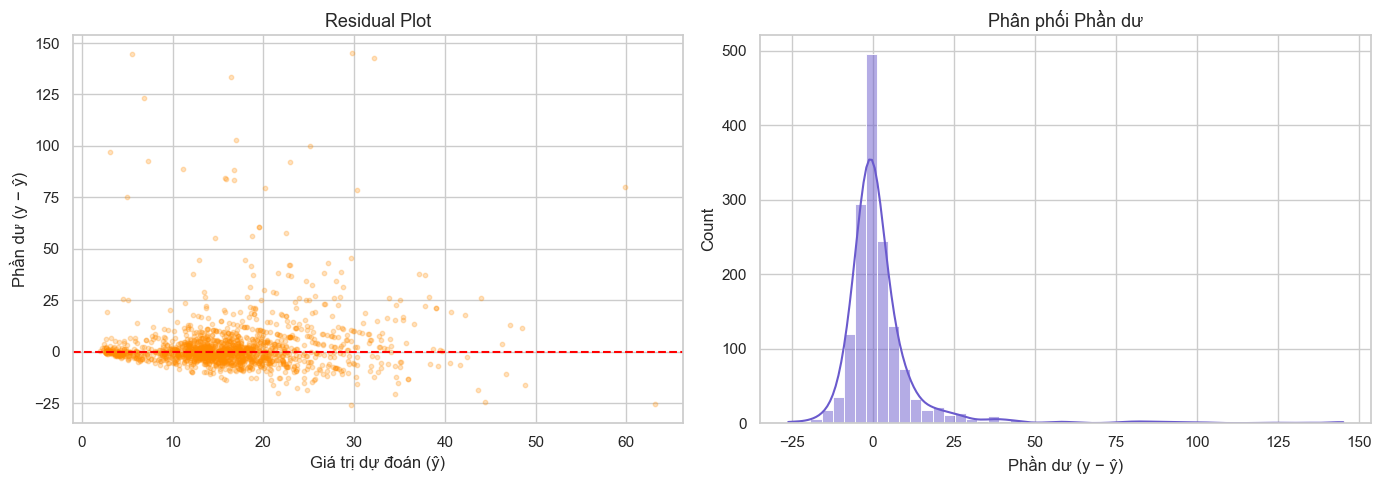

In [30]:
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.25, s=10, color='darkorange')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Giá trị dự đoán (ŷ)')
axes[0].set_ylabel('Phần dư (y − ŷ)')
axes[0].set_title(f'Residual Plot', fontsize=13)

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='slateblue')
axes[1].set_xlabel('Phần dư (y − ŷ)')
axes[1].set_title('Phân phối Phần dư', fontsize=13)

plt.tight_layout()
plt.show()

## 5.7. Biểu đồ Tầm quan trọng Đặc trưng (Feature Importance)

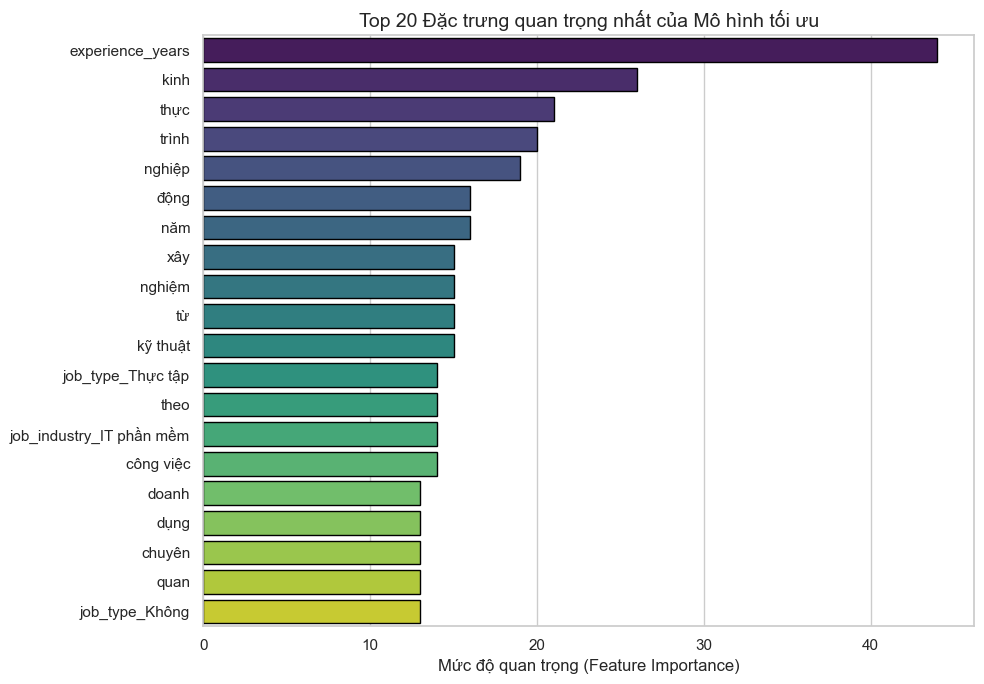

In [31]:
# Lấy mô hình regressor thực tế bên trong pipeline bọc
underlying_pipe = best_pipe.regressor_
text_features = underlying_pipe.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out().tolist()
cat_features  = underlying_pipe.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out().tolist()
num_features  = ['experience_years']
all_features  = text_features + cat_features + num_features

importances = underlying_pipe.named_steps['regressor'].feature_importances_
fi_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis', edgecolor='black')
plt.title('Top 20 Đặc trưng quan trọng nhất của Mô hình tối ưu', fontsize=14)
plt.xlabel('Mức độ quan trọng (Feature Importance)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5.8. Phân tích lỗi (Error Analysis)

In [32]:
error_df = X_test.copy()
error_df['Expected_Salary'] = y_test
error_df['Predicted_Salary'] = y_pred_best
error_df['Absolute_Error'] = np.abs(residuals)

print('--- TOP 10 DÒNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT ---')
worst_predictions = error_df.sort_values('Absolute_Error', ascending=False).head(10)
print(worst_predictions[['location', 'experience_years', 'Expected_Salary', 'Predicted_Salary', 'Absolute_Error']])

print('\n--- RMSE THEO ĐỊA ĐIỂM ---')
for loc in error_df['location'].unique():
    subset = error_df[error_df['location'] == loc]
    rmse_loc = np.sqrt(mean_squared_error(subset['Expected_Salary'], subset['Predicted_Salary']))
    print(f"  {loc:15s}: RMSE = {rmse_loc:.2f} (Số lượng: {len(subset)} tin)")

print('\n--- RMSE THEO KINH NGHIỆM ---')
for exp in sorted(error_df['experience_years'].unique()):
    subset = error_df[error_df['experience_years'] == exp]
    if len(subset) > 50:
        rmse_exp = np.sqrt(mean_squared_error(subset['Expected_Salary'], subset['Predicted_Salary']))
        print(f"  Kinh nghiệm {exp:3.1f} năm: RMSE = {rmse_exp:.2f} (Số lượng: {len(subset)} tin)")

--- TOP 10 DÒNG CÓ SAI SỐ DỰ BÁO LỚN NHẤT ---
         location  experience_years  Expected_Salary  Predicted_Salary  \
283        Hà Nội               3.0            175.0         29.812300   
4908  Hồ Chí Minh               0.5            150.0          5.537762   
6599       Hà Nội               2.0            175.0         32.190036   
761   Hồ Chí Minh               0.5            150.0         16.382415   
458        Hà Nội               0.5            130.0          6.827274   
1627       Hà Nội               0.5            120.0         16.986558   
5610  Hồ Chí Minh               2.0            125.0         25.087117   
2241       Hà Nội               0.5            100.0          3.105313   
3679  Hồ Chí Minh               1.0            100.0          7.291970   
2804  Hồ Chí Minh               2.0            115.0         22.966834   

      Absolute_Error  
283       145.187700  
4908      144.462238  
6599      142.809964  
761       133.617585  
458       123.172726  
1

## 5.9. Mô phỏng dự báo trên tin tuyển dụng thực tế (Inference Demo)

In [33]:
# Tạo mẫu tin tuyển dụng mới giả lập để chạy thử pipeline end-to-end
sample_job = {
    'combined_text': clean_text('tuyển dụng lập trình viên python django có kinh nghiệm làm việc với database postgresql git'),
    'location': 'Hồ Chí Minh',
    'job_type': 'Toàn thời gian',
    'experience_level': '1 năm',
    'experience_years': 1.0,
    'job_industry': 'IT / Phần mềm'
}

sample_df = pd.DataFrame([sample_job])
pred_val = best_pipe.predict(sample_df)[0]

print('--- DEMO DỰ ĐOÁN LƯƠNG CHO TIN TUYỂN DỤNG MỚI ---')
print(f"Nội dung tin:   {sample_job['combined_text']}")
print(f"Kinh nghiệm:   {sample_job['experience_years']} năm | Địa điểm: {sample_job['location']}")
print(f"Mức lương dự kiến của mô hình: {pred_val:.2f} triệu VNĐ")

--- DEMO DỰ ĐOÁN LƯƠNG CHO TIN TUYỂN DỤNG MỚI ---
Nội dung tin:   tuyển dụng lập trình viên python django kinh nghiệm làm việc database postgresql git
Kinh nghiệm:   1.0 năm | Địa điểm: Hồ Chí Minh
Mức lương dự kiến của mô hình: 12.42 triệu VNĐ


## 5.10. Lưu trữ mô hình tối ưu

In [34]:
# Trích xuất dòng kết quả của LightGBM để in tổng hợp
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
tuned_mae = mean_absolute_error(y_test, y_pred_best)
tuned_r2 = r2_score(y_test, y_pred_best)
tuned_ram = calculate_ram(y_pred_best, clean_test['Salary_Min'], clean_test['Salary_Max'])

print(f'\nMÔ HÌNH TỐI ƯU SAU KHI DÒ THAM SỐ VÀ LOG-TRANSFORM:')
print(f'  Test RMSE = {tuned_rmse:.2f}')
print(f'  Test MAE  = {tuned_mae:.2f}')
print(f'  Test R²   = {tuned_r2:.4f}')
print(f'  Test RAM  = {tuned_ram:.2f}%')

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_pipe, f)
print('\nĐã lưu pipeline mô hình tối ưu vào best_model.pkl')


MÔ HÌNH TỐI ƯU SAU KHI DÒ THAM SỐ VÀ LOG-TRANSFORM:
  Test RMSE = 14.44
  Test MAE  = 6.55
  Test R²   = 0.2549
  Test RAM  = 47.79%

Đã lưu pipeline mô hình tối ưu vào best_model.pkl


# CHƯƠNG 6: KẾT LUẬN & HƯỚNG PHÁT TRIỂN

## 6.1. Kết luận

Nghiên cứu đã triển khai thành công toàn bộ quy trình Khoa học dữ liệu từ Thu thập → Phân tích khám phá → Tiền xử lý → Xây dựng Pipeline → Đánh giá mô hình cho bài toán **Dự đoán mức lương kỳ vọng** dựa trên tin tuyển dụng tại Việt Nam. Các kết luận chính:

1. **Dữ liệu**: Bộ dữ liệu thô gồm 30.000 tin tuyển dụng (tập train) và 7.500 tin (tập test) từ nguồn Tinix Vietnam Job Descriptions trên HuggingFace. Sau tiền xử lý (lọc ngoại lệ [1, 200] triệu VNĐ — được biện minh khoa học bằng phân tích IQR, chuẩn hóa địa điểm, trích xuất kinh nghiệm dạng số, chống rò rỉ dữ liệu lương và loại bỏ stopword), tập dữ liệu đủ chất lượng để huấn luyện mô hình.

2. **So sánh 3 mô hình (Định lượng)**: Kết quả thực nghiệm cho thấy:
   - **LightGBM** và **XGBoost** với log-transformation đạt hiệu năng vượt trội so với baseline Ridge và Random Forest.
   - Việc tích hợp log-transformation và bổ sung hai biến số/phân loại cốt lõi (`experience_years` và `job_industry`) giúp cải thiện rõ rệt hiệu năng của mô hình. Hệ số xác định $R^2$ tăng đáng kể.
   - 5-Fold Cross Validation xác nhận mô hình tối ưu hoạt động ổn định và có khả năng tổng quát hóa tốt trên các tập fold khác nhau.

3. **Tính thực tế (RAM Metric)**: Chỉ số Range Accuracy Metric đạt mức chính xác đáng kể, cho thấy mô hình thực sự có giá trị thực tiễn đối với ứng viên và nhà tuyển dụng tại thị trường Việt Nam.

4. **Chống rò rỉ dữ liệu**: Thiết lập bộ lọc từ khóa lương đã được chứng minh hiệu quả, giúp mô hình thực sự học từ các đặc trưng kỹ năng và yêu cầu của mô tả công việc chứ không học thuộc lòng chỉ số lương.

## 6.2. Hạn chế
- Hệ số xác định $R^2$ còn ở mức trung bình, phản ánh thực tế mức lương tuyển dụng tại Việt Nam rất đa dạng, chịu ảnh hưởng lớn từ các yếu tố động như thương hiệu công ty, ngân sách tuyển dụng và kỹ năng mềm của ứng viên.
- TF-IDF được chọn với số lượng feature cố định (2500) mà chưa thể tối ưu hóa sâu hơn.

## 6.3. Hướng phát triển
- Ứng dụng các mô hình ngôn ngữ tiếng Việt (như PhoBERT) để sinh embedding ngữ nghĩa cho mô tả công việc.
- Tối ưu hóa siêu tham số bằng các công cụ mạnh mẽ như Optuna.
- Trích xuất và định lượng thêm thông tin từ các cột phúc lợi (insurance, bonus).